In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
from src.data_cleaning import load_and_clean_data

@st.cache_data
def get_data():
    return load_and_clean_data("data/Online Retail Data Set.csv")

df = get_data()

df.head()

ModuleNotFoundError: No module named 'src'

In [3]:
from src.rfm_analysis import calculate_rfm

rfm = calculate_rfm(df)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,95,5,2540.29
12348.0,220,1,367.00
12350.0,311,1,334.40
12352.0,274,3,1296.38
12355.0,96,1,459.40


In [4]:
from src.clustering import perform_clustering

rfm_clustered = perform_clustering(rfm)

rfm_clustered.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,95,5,2540.29,0
12348.0,220,1,367.00,1
12350.0,311,1,334.40,1
12352.0,274,3,1296.38,1
12355.0,96,1,459.40,0


In [5]:
rfm_clustered["Cluster"].value_counts()

Cluster
0    2066
1     862
2      65
3       4
Name: count, dtype: int64

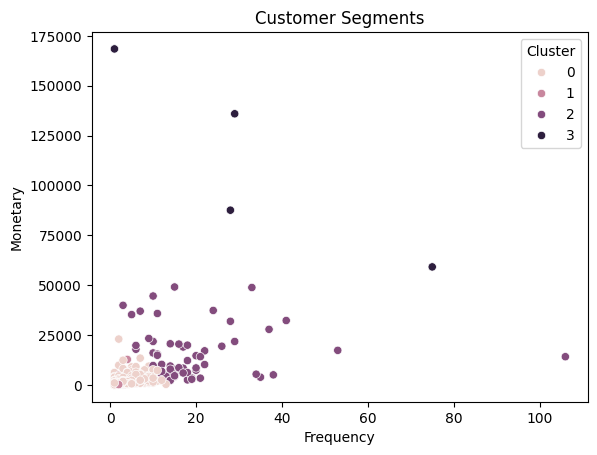

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=rfm_clustered["Frequency"],
    y=rfm_clustered["Monetary"],
    hue=rfm_clustered["Cluster"]
)

plt.title("Customer Segments")
plt.show()